# Synthetic Effective Rank / Spectral Ratio Playground

This notebook builds four synthetic adjacency matrices that capture the High/Low combinations of Effective Rank (ER) and Spectral Ratio (SR) so we can recreate the heatmap and t-SNE visuals with fully controllable data.

### Framing the scenarios
- **Effective Rank (ER)** captures how many eigen-directions meaningfully contribute to the structure of the adjacency matrix.
- **Spectral Ratio (SR)** is defined here as $\lambda_1 / \lambda_2$; higher values indicate a dominant leading eigenvalue.
- We create four synthetic regimes: High/Low ER × High/Low SR (HH, HL, LH, LL) by shaping eigenvalue decay and the first-eigenvalue gap.

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

sns.set_theme(style="white", context="talk")
STYLE_OVERRIDES = {
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#f8f9fb',
    'axes.edgecolor': '#e0e0e0',
    'axes.titleweight': 'semibold',
    'axes.titlepad': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'font.size': 13,
}
plt.rcParams.update(STYLE_OVERRIDES)
np.set_printoptions(precision=3, suppress=True)
HEATMAP_CMAP = "rocket_r"
TSNE_POINT_COLOR = "#2460a7"
TSNE_POINT_EDGE = "#0f3057"

In [28]:
def generate_eigenvalues(n_nodes: int, decay: float, gap: float, floor: float = 1e-3) -> np.ndarray:
    base = np.exp(-decay * np.arange(n_nodes))
    base[0] *= gap
    eigvals = np.sort(base)[::-1] + floor
    return eigvals

def synthesize_adjacency(n_nodes: int, decay: float, gap: float, seed: int, floor: float = 1e-3) -> np.ndarray:
    rng = np.random.default_rng(seed)
    q, _ = np.linalg.qr(rng.normal(size=(n_nodes, n_nodes)))
    eigvals = generate_eigenvalues(n_nodes, decay, gap, floor=floor)
    mat = q @ np.diag(eigvals) @ q.T
    max_abs = np.max(np.abs(mat))
    if max_abs > 0:
        mat = mat / max_abs
    else:
        mat = np.zeros_like(mat)
    return mat

def make_lowrank_matrix(n_nodes: int, weights: list[float], noise: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    mat = np.zeros((n_nodes, n_nodes))
    basis: list[np.ndarray] = []
    for weight in weights:
        vec = rng.normal(size=n_nodes)
        for prev in basis:
            vec -= np.dot(vec, prev) * prev
        vec_norm = np.linalg.norm(vec)
        if vec_norm == 0:
            continue
        vec /= vec_norm
        basis.append(vec)
        mat += weight * np.outer(vec, vec)
    mat = 0.5 * (mat + mat.T)
    if noise > 0:
        mat += rng.normal(0, noise, size=(n_nodes, n_nodes))
        mat = 0.5 * (mat + mat.T)
    max_abs = np.max(np.abs(mat))
    if max_abs > 0:
        mat /= max_abs
    return mat

def add_symmetric_noise(mat: np.ndarray, rng: np.random.Generator, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return mat
    noise = rng.normal(0, sigma, size=mat.shape)
    noise = 0.5 * (noise + noise.T)
    return mat + noise

def effective_rank(eigvals: np.ndarray, tol: float = 1e-12) -> float:
    eigvals = eigvals[eigvals > tol]
    if eigvals.size == 0:
        return 0.0
    probs = eigvals / eigvals.sum()
    return float(np.exp(-np.sum(probs * np.log(probs))))

def spectral_ratio(eigvals: np.ndarray) -> float:
    abs_vals = np.sort(np.abs(eigvals))[::-1]
    if abs_vals.size < 2 or abs_vals[1] < 1e-12:
        return float('inf')
    return float(abs_vals[0] / abs_vals[1])

def scale_for_display(mat: np.ndarray) -> np.ndarray:
    min_v, max_v = mat.min(), mat.max()
    span = max_v - min_v
    if span == 0:
        return np.zeros_like(mat)
    return (mat - min_v) / span

def map_to_cosine_range(mat: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms < 1e-12] = 1.0
    normalized = mat / norms
    cos_sim = normalized @ normalized.T
    return np.clip(cos_sim, -1.0, 1.0)

In [29]:
profiles = {
    "High ER + High SR": {
        "decay": 0.018,
        "gap": 20.0,
        "seed": 1,
        "floor": 5e-3,
        "er_level": "High",
        "sr_level": "High",
        "mix_lowrank_weight": 0.05,
        "mix_lowrank_profile": [1.0, 0.995, 0.99, 0.985, 0.98, 0.975],
        "mix_lowrank_noise": 0.01,
        "spectral_noise": 0.08
    },
    "High ER + Low SR": {
        "decay": 0.05,
        "gap": 1.08,
        "seed": 22,
        "floor": 5e-3,
        "er_level": "High",
        "sr_level": "Low",
        "spectral_noise": 0.04
    },
    "Low ER + High SR": {
        "seed": 33,
        "er_level": "Low",
        "sr_level": "High",
        "mode": "uniform",
        "uniform_row_noise": 0.02,
        "uniform_col_noise": 0.02,
        "uniform_global_noise": 0.001
    },
    "Low ER + Low SR": {
        "seed": 44,
        "er_level": "Low",
        "sr_level": "Low",
        "mode": "lowrank",
        "rank_weights": [1.0, 0.98],
        "noise": 0.0,
        "lowrank_jitter": 0.002
    }
}

n_nodes = 170
adjacency_mats = {}
metrics = []

for scenario, cfg in profiles.items():
    rng = np.random.default_rng(cfg["seed"])
    mode = cfg.get("mode", "spectral")
    if mode == "uniform":
        row_noise = cfg.get("uniform_row_noise", 0.01)
        col_noise = cfg.get("uniform_col_noise", 0.01)
        jitter_noise = cfg.get("uniform_global_noise", 0.002)
        row_offsets = rng.normal(0, row_noise, size=(n_nodes, 1))
        col_offsets = rng.normal(0, col_noise, size=(1, n_nodes))
        mat = np.ones((n_nodes, n_nodes)) + row_offsets + col_offsets
        if jitter_noise > 0:
            jitter = rng.normal(0, jitter_noise, size=(n_nodes, n_nodes))
            jitter = 0.5 * (jitter + jitter.T)
            mat += jitter
    elif mode == "lowrank":
        weights = cfg.get("rank_weights", [0.7, 0.65])
        noise = cfg.get("noise", 0.015)
        mat = make_lowrank_matrix(n_nodes, weights, noise, cfg["seed"])
        jitter = cfg.get("lowrank_jitter", 0.0)
        if jitter > 0:
            mat = add_symmetric_noise(mat, rng, jitter)
        max_abs = np.max(np.abs(mat))
        if max_abs > 0:
            mat /= max_abs
    else:
        mat = synthesize_adjacency(n_nodes, cfg["decay"], cfg["gap"], cfg["seed"], floor=cfg.get("floor", 1e-3))
        mix_weight = cfg.get("mix_lowrank_weight", 0.0)
        if mix_weight > 0:
            lr_weights = cfg.get("mix_lowrank_profile", [1.0, 0.9, 0.8])
            lr_noise = cfg.get("mix_lowrank_noise", 0.0)
            lr_seed = cfg.get("mix_lowrank_seed", cfg["seed"] + 101)
            lowrank = make_lowrank_matrix(n_nodes, lr_weights, lr_noise, lr_seed)
            mat = (1 - mix_weight) * mat + mix_weight * lowrank
        spectral_noise = cfg.get("spectral_noise", 0.0)
        if spectral_noise > 0:
            mat = add_symmetric_noise(mat, rng, spectral_noise)
        max_abs = np.max(np.abs(mat))
        if max_abs > 0:
            mat /= max_abs
    mat = map_to_cosine_range(mat)
    adjacency_mats[scenario] = mat
    eigvals = np.linalg.eigvalsh(mat)
    eigvals = np.sort(eigvals)[::-1]
    metrics.append({
        "Scenario": scenario,
        "ER label": cfg["er_level"],
        "SR label": cfg["sr_level"],
        "Effective Rank": round(effective_rank(eigvals), 2),
        "Spectral Ratio": round(spectral_ratio(eigvals), 2)
    })

metrics_df = pd.DataFrame(metrics).set_index("Scenario")
metrics_df

,ER label,SR label,Effective Rank,Spectral Ratio
Scenario,,,,
High ER + High SR,High,High,19.58,26.33
High ER + Low SR,High,Low,33.82,1.16
Low ER + High SR,Low,High,1.00,6665539.73
Low ER + Low SR,Low,Low,2.02,1.12


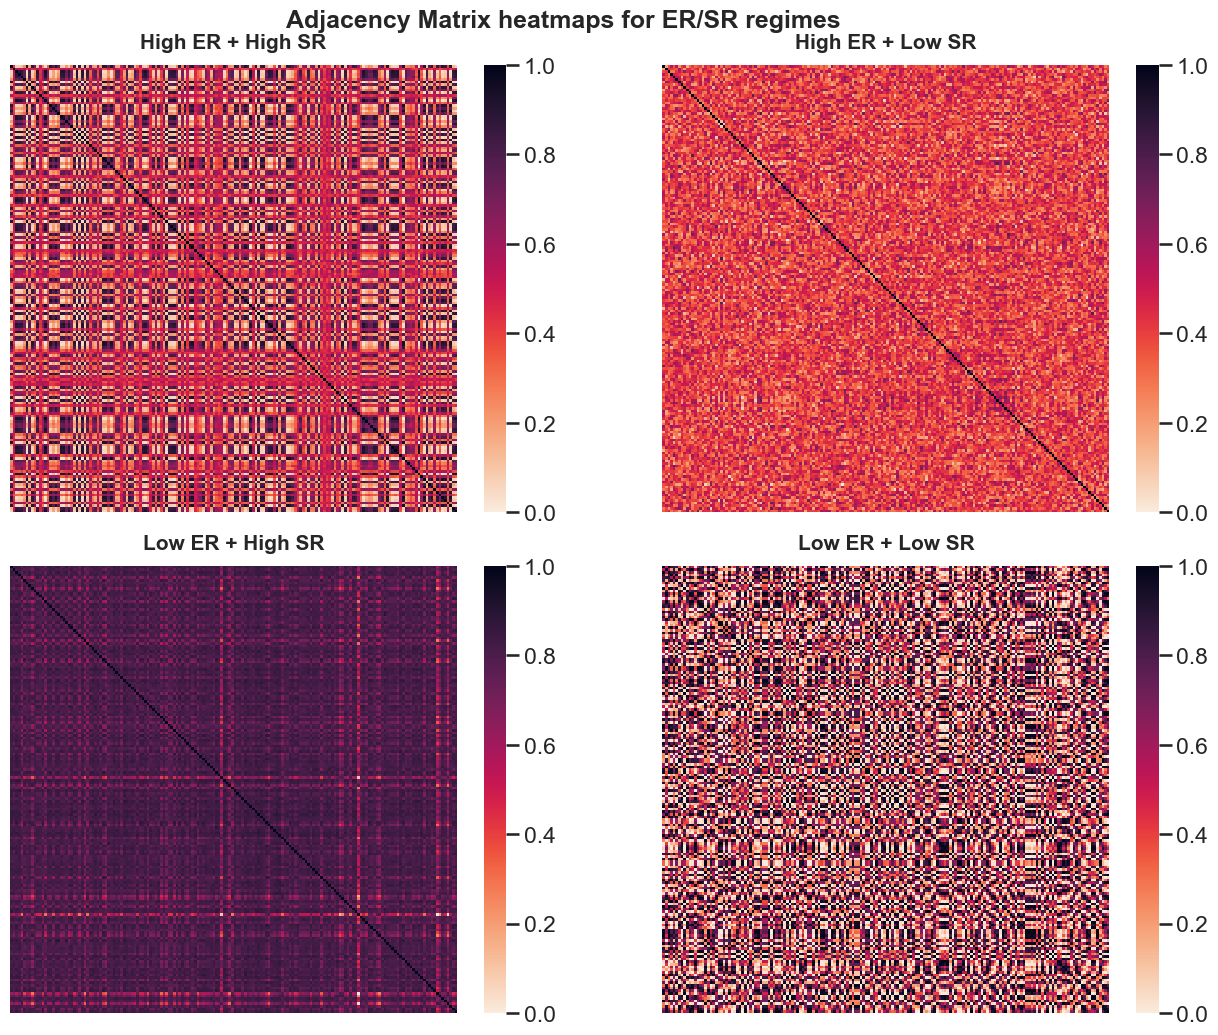

In [30]:
metric_lookup = metrics_df.copy()
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
fig.patch.set_alpha(1)

for ax, (scenario, mat) in zip(axes.flat, adjacency_mats.items()):
    display_mat = scale_for_display(mat)
    sns.heatmap(
        display_mat,
        ax=ax,
        cmap=HEATMAP_CMAP,
        square=True,
        cbar=True,
        # cbar_kws={"shrink": 0.7, "label": "Normalized weight"},
        linewidths=0.0,
        xticklabels=False,
        yticklabels=False,
    )
    stats = metric_lookup.loc[scenario]
    title = f"{scenario}"
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_facecolor("white")
    midpoint = display_mat.shape[0] // 2
    # ax.text(midpoint, -2.5, ha="center", va="center", fontsize=11, color="#5c5c5c")
    # ax.text(-2.5, midpoint, "Rows", ha="center", va="center", rotation=90, fontsize=11, color="#5c5c5c")
    for spine in ax.spines.values():
        spine.set_visible(False)

sns.despine(fig=fig, left=True, bottom=True)
fig.suptitle("Adjacency Matrix heatmaps for ER/SR regimes", y=1.02, fontsize=18, weight="bold")
plt.show()

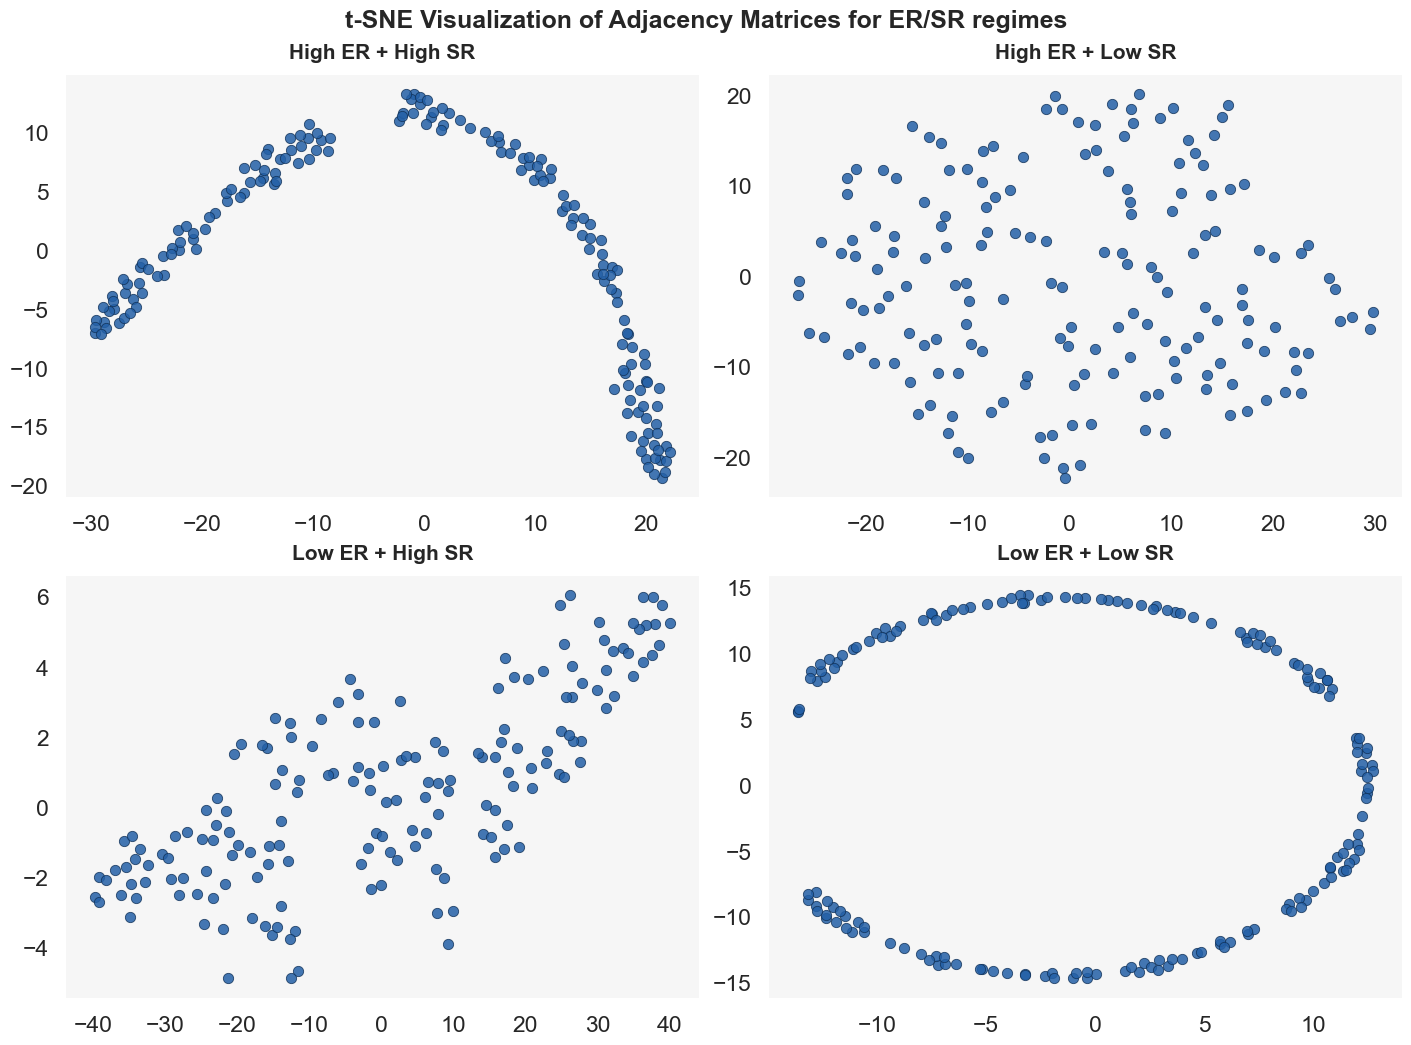

In [31]:
tsne_params = dict(n_components=2, perplexity=15, random_state=42, init="pca")
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.patch.set_alpha(1)

for ax, (scenario, mat) in zip(axes.flat, adjacency_mats.items()):
    embedding = TSNE(**tsne_params).fit_transform(mat)
    stats = metric_lookup.loc[scenario]
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], ax=ax, s=55,
                    color=TSNE_POINT_COLOR, edgecolor=TSNE_POINT_EDGE, linewidth=0.6, alpha=0.85)
    ax.set_title(f"{scenario}", fontsize=15, pad=12)
    # ax.set_xlabel("t-SNE dim 1")
    # ax.set_ylabel("t-SNE dim 2")
    ax.set_facecolor("#f6f6f6")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("t-SNE Visualization of Adjacency Matrices for ER/SR regimes", y=1.03, fontsize=18, weight="bold")
plt.show()

/var/folders/sl/z3d890mn17l_7cs33yph77p00000gp/T/ipykernel_1508/1671253032.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


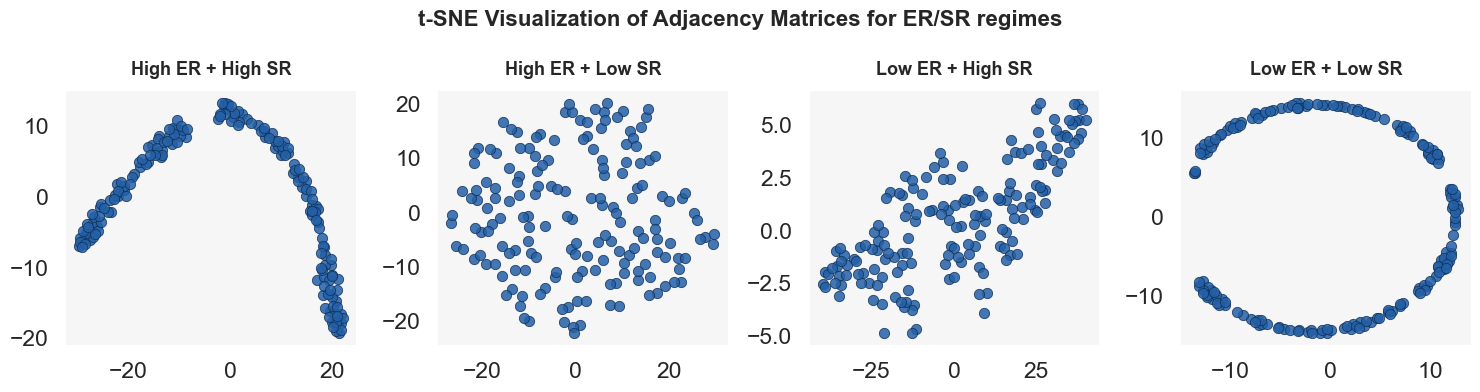

In [32]:
tsne_params = dict(n_components=2, perplexity=15, random_state=42, init="pca")
fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
fig.patch.set_alpha(1)

for ax, (scenario, mat) in zip(axes.flat, adjacency_mats.items()):
    embedding = TSNE(**tsne_params).fit_transform(mat)
    stats = metric_lookup.loc[scenario]
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], ax=ax, s=55,
                    color=TSNE_POINT_COLOR, edgecolor=TSNE_POINT_EDGE, linewidth=0.6, alpha=0.85)
    ax.set_title(f"{scenario}", fontsize=13, pad=12)
    # ax.set_xlabel("t-SNE dim 1")
    # ax.set_ylabel("t-SNE dim 2")
    ax.set_facecolor("#f6f6f6")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("t-SNE Visualization of Adjacency Matrices for ER/SR regimes",  fontsize=16, weight="bold")
plt.tight_layout()
plt.show()